# End-to-End EDA + Visualization + Modeling Notebook

This notebook connects to the Postgres warehouse, runs exploratory data analysis, creates features, trains a model, and evaluates performance.

In [9]:
# 1. Setup and imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

sns.set(style="whitegrid")

# PostgreSQL connection string - adjust user/password as needed
engine = create_engine("postgresql://huseyn@localhost:5432/b2b_credit_risk")

In [10]:
# 2. Load data from Postgres (via DBeaver connection credentials)
query= """
SELECT * FROM credit_risk_dw.fact_exposure_snapshot LIMIT 10;
"""
print(pd.read_sql(query, engine).head())

# Pivots of key tables used in modeling
fact_exposure = pd.read_sql("SELECT * FROM credit_risk_dw.fact_exposure_snapshot", engine)
fact_default = pd.read_sql("SELECT * FROM credit_risk_dw.fact_default_event", engine)
dim_customer = pd.read_sql("SELECT * FROM credit_risk_dw.dim_customer", engine)

   exposure_snapshot_key  customer_key  snapshot_date_key  rating_key  \
0                      1             1           20230430           5   
1                      2             1           20230531           5   
2                      3             1           20230630           6   
3                      4             1           20230731           6   
4                      5             1           20230831           5   

   monthly_sales_estimate  invoice_count_month  current_exposure  \
0             21521660.86                   31       15442996.98   
1             21351200.65                   31       15268648.49   
2             20754469.03                   25       15126795.38   
3             20890662.70                   24       14859767.53   
4             19044513.09                   17       13758533.76   

   overdue_exposure  overdue_ratio  insured_limit  utilization_ratio  \
0        2211130.64         0.1432    21067403.56             0.6640   
1       

In [11]:
# 3. EDA summaries
print("fact_exposure", fact_exposure.shape)
print("fact_default", fact_default.shape)
print("dim_customer", dim_customer.shape)

print(fact_exposure.describe())
print(fact_default['default_amount'].describe())

# distribution of target: defaults by customer
cust_defaults = fact_default.groupby('customer_key').size().reset_index(name='n_defaults')
print(cust_defaults.n_defaults.value_counts())

fact_exposure (384221, 20)
fact_default (8011, 9)
dim_customer (10000, 15)
       exposure_snapshot_key   customer_key  snapshot_date_key     rating_key  \
count          384221.000000  384221.000000       3.842210e+05  384221.000000   
mean           192111.000000    4999.814630       2.023769e+07       3.898254   
std            110915.193227    2886.727618       1.096806e+04       1.191785   
min                 1.000000       1.000000       2.022013e+07       1.000000   
25%             96056.000000    2502.000000       2.023043e+07       3.000000   
50%            192111.000000    5006.000000       2.024043e+07       4.000000   
75%            288166.000000    7497.000000       2.025033e+07       5.000000   
max            384221.000000   10000.000000       2.025123e+07       7.000000   

       monthly_sales_estimate  invoice_count_month  current_exposure  \
count            3.842210e+05        384221.000000      3.842210e+05   
mean             8.370399e+06            16.653910 

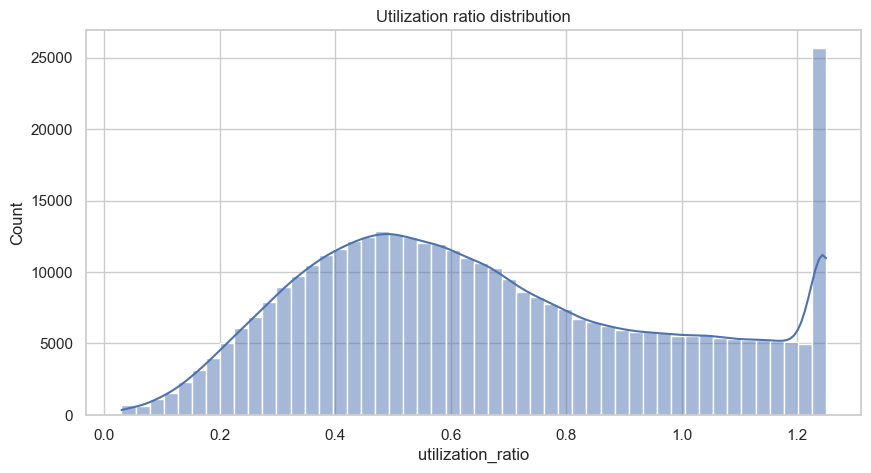

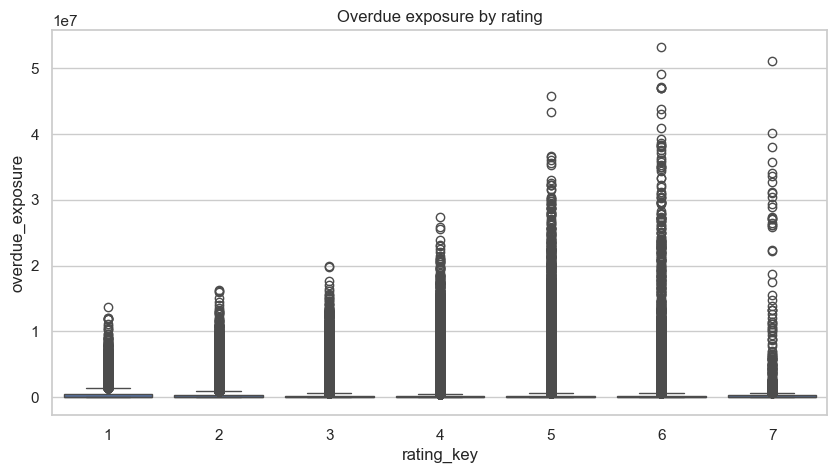

In [12]:
# 4. Visualizations
plt.figure(figsize=(10,5))
sns.histplot(fact_exposure['utilization_ratio'], bins=50, kde=True)
plt.title('Utilization ratio distribution')
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=fact_exposure, x='rating_key', y='overdue_exposure')
plt.title('Overdue exposure by rating')
plt.show()

In [13]:
# 5. Feature engineering
# Use phase 2 model features and match to default label (simplified)
features = fact_exposure.groupby('customer_key').agg(
    current_exposure=('current_exposure','mean'),
    overdue_exposure=('overdue_exposure','mean'),
    utilization_ratio=('utilization_ratio','mean'),
    avg_sales=('monthly_sales_estimate','mean'),
    invoice_count=('invoice_count_month','mean'),
    rating_key=('rating_key','max')
).reset_index()

labels = (fact_default.groupby('customer_key')
          .size().reset_index(name='has_default'))
labels['has_default'] = (labels['has_default'] > 0).astype(int)

data = features.merge(labels, on='customer_key', how='left').fillna(0)
print(data.head())

   customer_key  current_exposure  overdue_exposure  utilization_ratio  \
0             1      1.544987e+07      3.218254e+06           0.694239   
1             2      1.942860e+07      2.137784e+06           0.452623   
2             3      8.440516e+04      1.052686e+04           0.435602   
3             4      5.480293e+04      1.226523e+04           1.213359   
4             5      7.796773e+05      1.115958e+05           1.091009   

      avg_sales  invoice_count  rating_key  has_default  
0  2.114420e+07      23.696970           6          1.0  
1  5.045623e+07      65.270833           4          0.0  
2  1.471907e+05       4.414634           5          1.0  
3  1.283404e+05       4.097561           6          1.0  
4  1.771213e+06      10.411765           5          1.0  


In [14]:
# 6. Training and evaluation
X = data[['current_exposure','overdue_exposure','utilization_ratio','avg_sales','invoice_count','rating_key']]
y = data['has_default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

         0.0       0.60      0.57      0.58       497
         1.0       0.89      0.91      0.90      2003

    accuracy                           0.84      2500
   macro avg       0.75      0.74      0.74      2500
weighted avg       0.84      0.84      0.84      2500

ROC AUC: 0.8741681240714381


In [15]:
# 7. Save model and results
import joblib
joblib.dump(model, '../models/eda_rf_default_model.pkl')

print('Saved model to ../models/eda_rf_default_model.pkl')

Saved model to ../models/eda_rf_default_model.pkl
